# Web Data Extraction: APIs & Web Scraping

In [14]:
# let us import the requests library, which help us make API calls.
import requests

In [15]:
# let us check what happens when we access a real API
response = requests.get("https://api.github.com")
print(response.status_code)  # should print 200 if the request was successful

200


In [16]:
print(response.text[:250])  # print the first 250 characters of the response text

{"current_user_url":"https://api.github.com/user","current_user_authorizations_html_url":"https://github.com/settings/connections/applications{/client_id}","authorizations_url":"https://api.github.com/authorizations","code_search_url":"https://api.gi


# APIs often return JSON

Most APIs send data in JSON format.

JSON looks like Python dictionaries, and stores data in pairs of labels and values.

requests can help us handle JSON easily.

In [17]:
# let us get structured JSON data from the API

data = response.json()  # parse the JSON response into a Python dictionary
print(type(data))

<class 'dict'>


In [18]:
# let us explore a value inside the API response.

print(data['current_user_url'])  # print the value associated with the 'current_user_url' key

https://api.github.com/user


# What is Web Scraping?

What if there is no API available?

We can collect data from websites by reading the HTML directly.

This technique is called web scraping.

Python makes this possible with the BeautifulSoup library.

In [19]:
# let us import the BeautifulSoup library for our scraping tasks.

from bs4 import BeautifulSoup

In [20]:
# let us download a simple web page to scrape.

url = "https://quotes.toscrape.com"
page = requests.get(url)
soup = BeautifulSoup(page.text, 'html.parser')

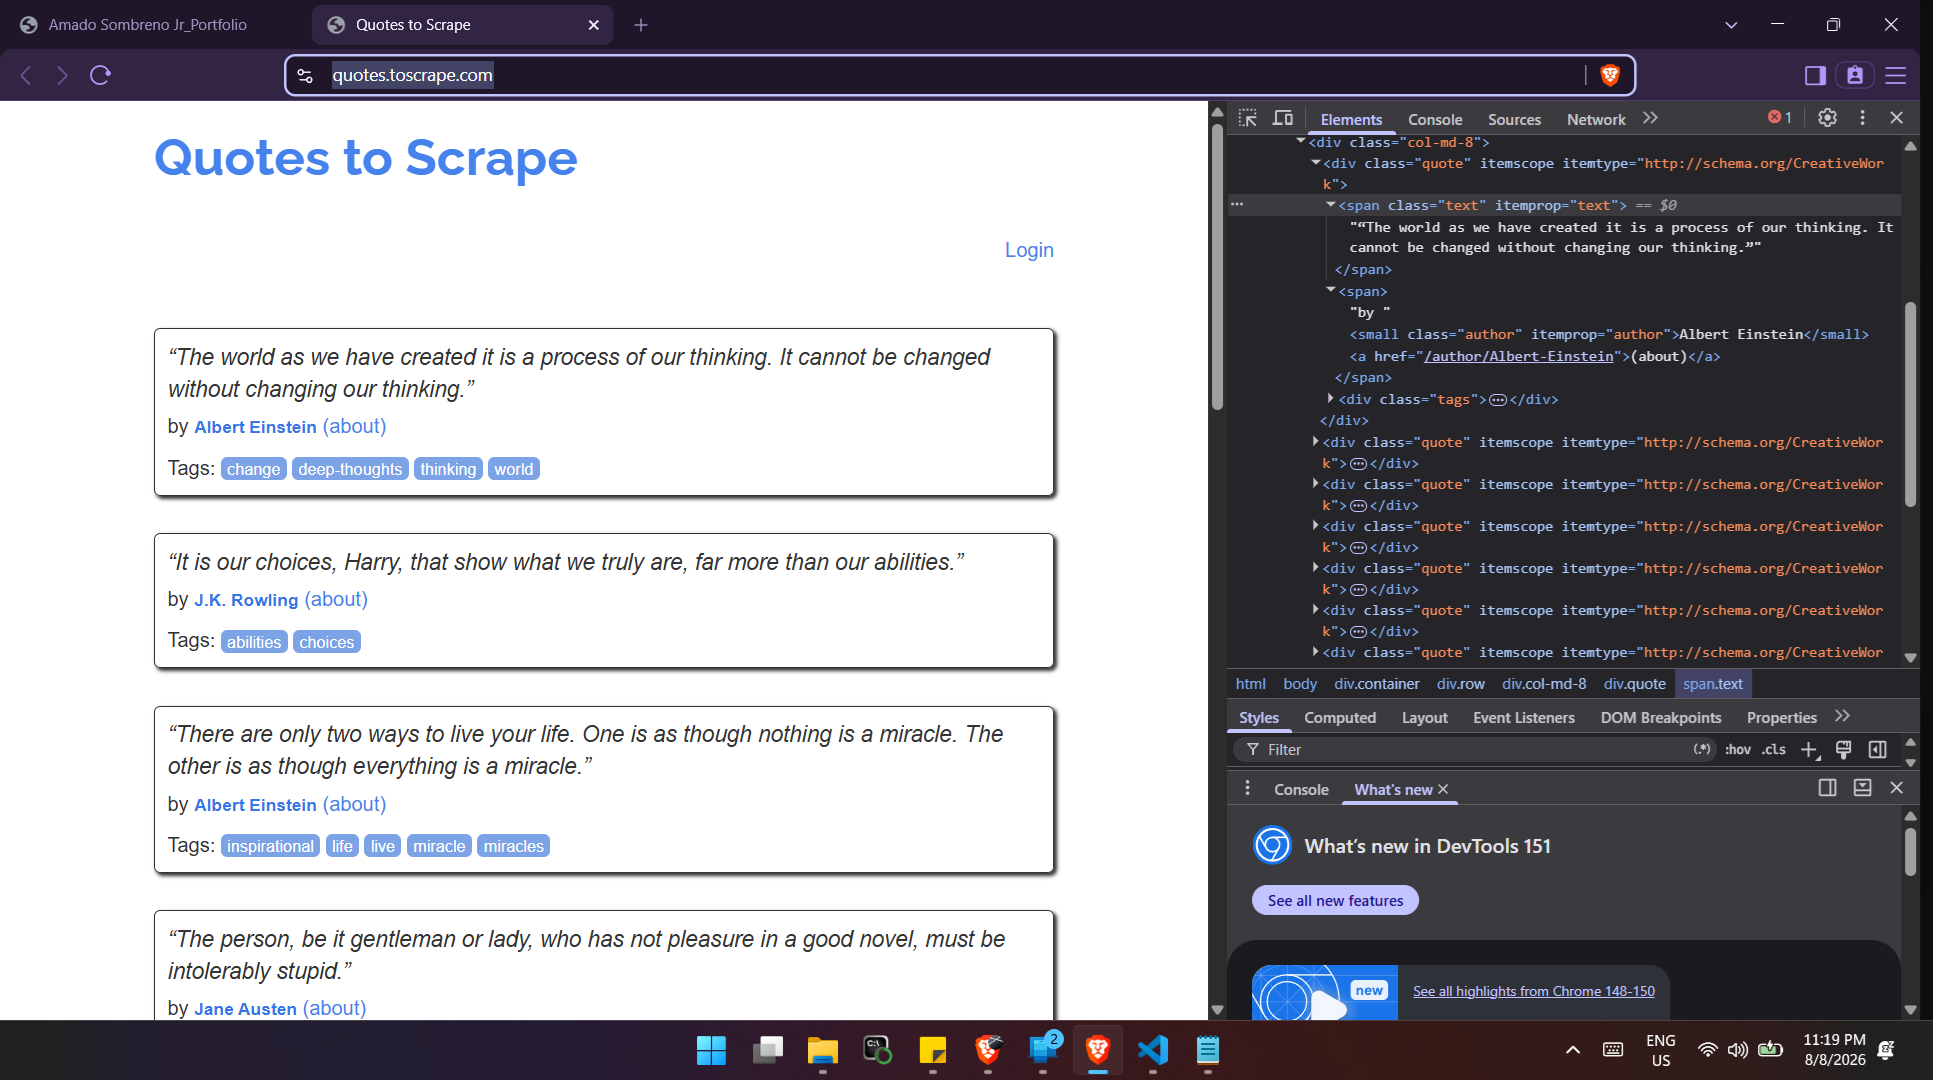

In [21]:
from IPython.display import display, Image

# Display a screenshot of the webpage being scraped
display(Image(filename="quotes.toscrape.png"))

In [22]:
# let us find all the quotes text on the page.

quotes = soup.find_all('span', class_='text')
for q in quotes:
    print(q.get_text())

“The world as we have created it is a process of our thinking. It cannot be changed without changing our thinking.”
“It is our choices, Harry, that show what we truly are, far more than our abilities.”
“There are only two ways to live your life. One is as though nothing is a miracle. The other is as though everything is a miracle.”
“The person, be it gentleman or lady, who has not pleasure in a good novel, must be intolerably stupid.”
“Imperfection is beauty, madness is genius and it's better to be absolutely ridiculous than absolutely boring.”
“Try not to become a man of success. Rather become a man of value.”
“It is better to be hated for what you are than to be loved for what you are not.”
“I have not failed. I've just found 10,000 ways that won't work.”
“A woman is like a tea bag; you never know how strong it is until it's in hot water.”
“A day without sunshine is like, you know, night.”


In [23]:
# let us grab authors of the quotes on the page.

authors = soup.find_all("small", class_="author")
for i in range(len(quotes)):
    print(f"{quotes[i].text} - {authors[i].text}")

“The world as we have created it is a process of our thinking. It cannot be changed without changing our thinking.” - Albert Einstein
“It is our choices, Harry, that show what we truly are, far more than our abilities.” - J.K. Rowling
“There are only two ways to live your life. One is as though nothing is a miracle. The other is as though everything is a miracle.” - Albert Einstein
“The person, be it gentleman or lady, who has not pleasure in a good novel, must be intolerably stupid.” - Jane Austen
“Imperfection is beauty, madness is genius and it's better to be absolutely ridiculous than absolutely boring.” - Marilyn Monroe
“Try not to become a man of success. Rather become a man of value.” - Albert Einstein
“It is better to be hated for what you are than to be loved for what you are not.” - André Gide
“I have not failed. I've just found 10,000 ways that won't work.” - Thomas A. Edison
“A woman is like a tea bag; you never know how strong it is until it's in hot water.” - Eleanor Roos

In [24]:
# Be gentle! let us pause between requests to avoid overwhelming the server. We can use the time library to add a delay.
import time
time.sleep(2)  # Pause for 2 seconds between requests
print("Waited for 2 seconds before making the next request.")

Waited for 2 seconds before making the next request.


# Handling errors the safe way

Not every web request will succeed.

Servers can be down, or you could have typed the address wrong.

We will now learn how to check if things are working, and handle any problems.

In [25]:
# Safe requests with error handling.

bad_url = "https://thisdoesnotexist.toscrape.com"
try:
    bad_response = requests.get(bad_url)
    bad_response.raise_for_status()
except requests.exceptions.RequestException as e:
    print(f"An error occurred: {e}")

An error occurred: 404 Client Error: Not Found for url: https://thisdoesnotexist.toscrape.com/


In [26]:
# Mini - project 1: Collect the first page of quotes and authors and save them to a file

all_quotes = []
for i in range(len(quotes)):
    all_quotes.append(f"{quotes[i].text} - {authors[i].text}")

with open("quotes_list.txt", "w", encoding="utf-8") as f:
    for line in all_quotes:
        f.write(line + "\n")

print("Saved quotes to quotes_list.txt!")

Saved quotes to quotes_list.txt!


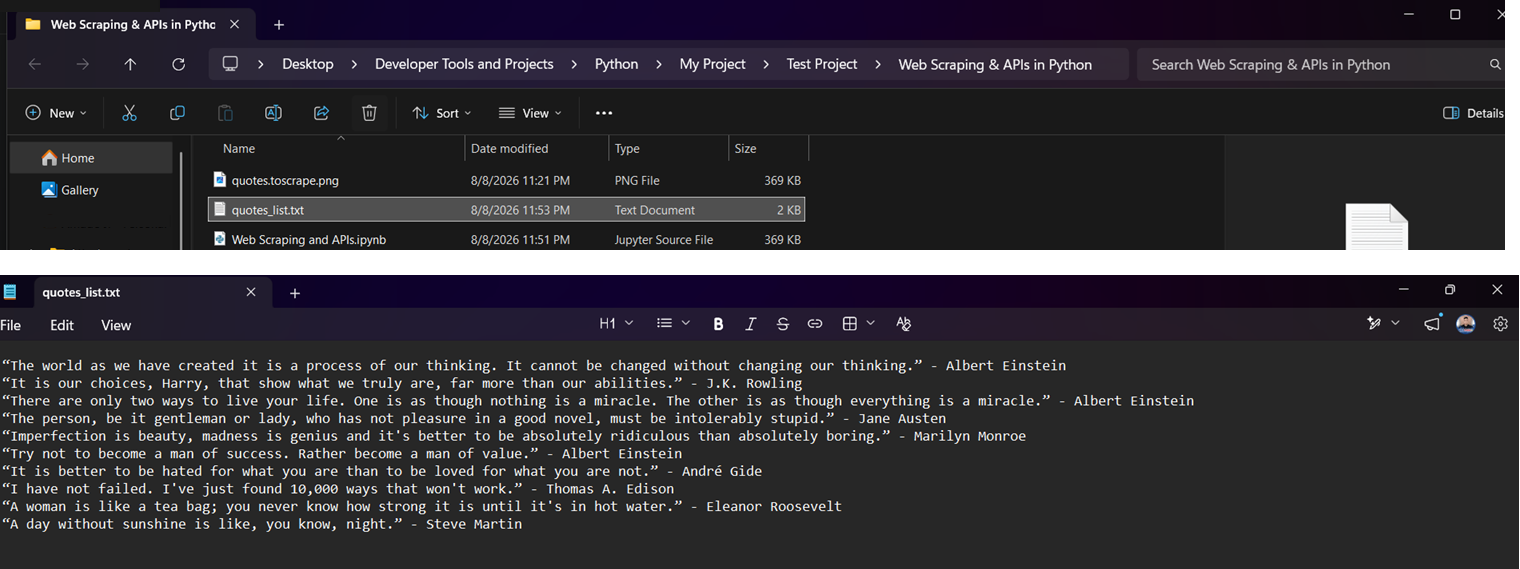

In [27]:
#  Display a screenshot of quotes_list.txt saved in the current working directory.

display(Image(filename="quotes_list_ss.png"))

In [28]:
# Mini - project 2: Count how many quotes on each the page contain the word "life"

life_quotes = []
for i in range(len(quotes)):
    if "life" in quotes[i].text.lower():
        life_quotes.append(f"{quotes[i].text} - {authors[i].text}")
print(f"Found {len(life_quotes)} quotes containing the word 'life':")
print(   "\n".join(life_quotes))

Found 1 quotes containing the word 'life':
“There are only two ways to live your life. One is as though nothing is a miracle. The other is as though everything is a miracle.” - Albert Einstein


In [29]:
# Sorting: let us find the longest quote on the page and print it.

longest_quote = max(quotes, key=lambda q: len(q.text))
print(f"The longest quote on the page is:\n{longest_quote.text}") 

The longest quote on the page is:
“There are only two ways to live your life. One is as though nothing is a miracle. The other is as though everything is a miracle.”


In [33]:
# Troubleshooting: What if nothing is returned when we try to scrape a page?
# Let us check if the page was downloaded successfully before we try to scrape it.

if not quotes:
    print("No quotes found on the page. Please check if the page structure has changed or if the URL is correct.")
else:
    print(f"Found {len(quotes)} quotes on the page.")
    for q in quotes:
        print(q.get_text())

# Scraping a list of links:
# Let us scrape all the links from the page and store them in a list.

Found 10 quotes on the page.
“The world as we have created it is a process of our thinking. It cannot be changed without changing our thinking.”
“It is our choices, Harry, that show what we truly are, far more than our abilities.”
“There are only two ways to live your life. One is as though nothing is a miracle. The other is as though everything is a miracle.”
“The person, be it gentleman or lady, who has not pleasure in a good novel, must be intolerably stupid.”
“Imperfection is beauty, madness is genius and it's better to be absolutely ridiculous than absolutely boring.”
“Try not to become a man of success. Rather become a man of value.”
“It is better to be hated for what you are than to be loved for what you are not.”
“I have not failed. I've just found 10,000 ways that won't work.”
“A woman is like a tea bag; you never know how strong it is until it's in hot water.”
“A day without sunshine is like, you know, night.”


In [36]:
# Extra tip: Adding header to look like a real browser.

headers = {"User-Agent": "Mozilla/5.0"}
custom_page = requests.get(url, headers=headers)
print(f"Custom request status code: {custom_page.status_code}")

# Adding a User-Agent Header
# A User-Agent header makes our request look like it is coming from a web browser. Some websites may block requests that look like they come from automated scripts.
# A status code of 200 means the webpage was successfully downloaded.


Custom request status code: 200


In [41]:
# Scraping the tags for each quote.

tags = soup.find_all("div", class_="tags")
for i in range(len(tags)):
    tags_texts = [t.text for t in tags[i].find_all("a", class_="tag")]
    print(f"{quotes[i].text} | Tags: {', '.join(tags_texts)}")


“The world as we have created it is a process of our thinking. It cannot be changed without changing our thinking.” | Tags: change, deep-thoughts, thinking, world
“It is our choices, Harry, that show what we truly are, far more than our abilities.” | Tags: abilities, choices
“There are only two ways to live your life. One is as though nothing is a miracle. The other is as though everything is a miracle.” | Tags: inspirational, life, live, miracle, miracles
“The person, be it gentleman or lady, who has not pleasure in a good novel, must be intolerably stupid.” | Tags: aliteracy, books, classic, humor
“Imperfection is beauty, madness is genius and it's better to be absolutely ridiculous than absolutely boring.” | Tags: be-yourself, inspirational
“Try not to become a man of success. Rather become a man of value.” | Tags: adulthood, success, value
“It is better to be hated for what you are than to be loved for what you are not.” | Tags: life, love
“I have not failed. I've just found 10,000

## Recap

* Used Python to **request and process data from APIs**.
* **Web scraped** data from websites without an API.
* Used **BeautifulSoup** to find and extract specific information from webpages.
* **Saved, sorted, and handled errors** when working with web data.
